# Phase 3 Step 2a — 종목별 LSTM 학습 (`02a_phase15_stockwise_extended.ipynb`)

> **목적**: Phase 1.5 v8 Performance-Weighted Ensemble 을 17 년 (2009~2025) **전체 S&P 500 universe** (~624 종목) 에
>          4-way 병렬 (RTX 4090 24GB) 로 학습·예측.

## 모델 구성 (Phase 1.5 v8 일관)

- **LSTM v4** (3ch_vix: rv_d, rv_w, rv_m + vix_log, IS=1250, embargo=63, hidden=32)
- **HAR-RV** (1d, 5d, 22d 이동평균 선형 회귀)
- **Ensemble** = Performance-Weighted (Diebold-Pauly rolling)

## 진행 상황 가시화 (재설계, 2026-04-29)

- `tqdm.auto` 진행 막대 (notebook + CMD 양쪽)
- 종목 완료마다 ETA·경과시간 출력 (`flush=True`)
- 매 20 종목마다 `ensemble_predictions_partial.csv` 중간 저장

## 실행 전 확인

1. `01_universe_extended.ipynb` 완료 (`universe_full_history.csv` + `daily_panel.csv`, 624 종목)
2. RTX 4090 24GB GPU 가용
3. CUDA + PyTorch 정상

## 산출물

| 파일 | 내용 |
|---|---|
| `data/ensemble_predictions_stockwise.csv` | 종목별 예측 (date, ticker, y_pred_lstm, y_pred_har, y_pred_ensemble, y_true) |

## 예상 시간

- **624 종목 × 4-way 병렬 (RTX 4090)**: 약 3~5 시간
- 8-way 대비 4-way: CUDA 컨텍스트 overhead ↓, 동일 또는 더 빠름

## 셀 구성

| § | 내용 |
|---|---|
| §1 | 환경 + 경로 |
| §2 | GPU 환경 확인 |
| §3 | 4-way 병렬 학습 실행 |
| §4 | 결과 검증 (RMSE 분포, best model 분포) |
| §5 | Phase 2 결과 비교 (공통 종목) |

## §1. 환경 부트스트랩

In [1]:
%load_ext autoreload
%autoreload 2

import sys, time
from pathlib import Path

NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts.setup import bootstrap, DATA_DIR, OUTPUTS_DIR

font_used = bootstrap()

OUT_DIR = OUTPUTS_DIR / '02a_stockwise'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'OUT_DIR: {OUT_DIR}')

  Phase 3 Robust Extensions — 환경 부트스트랩 완료
  한글 폰트   : Malgun Gothic
  시드        : 42
  데이터 경로  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\data
  Phase 1.5  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility
  Phase 2    : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration
OUT_DIR: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\outputs\02a_stockwise


## §2. GPU 환경 확인

In [2]:
import torch

print('=== GPU 환경 ===')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    free_mem = (torch.cuda.get_device_properties(0).total_memory
                - torch.cuda.memory_allocated(0)) / 1e9
    print(f'Total VRAM: {total_mem:.1f} GB')
    print(f'Free  VRAM: {free_mem:.1f} GB')
    assert free_mem >= 3.0, f'VRAM 부족: {free_mem:.1f} GB < 3 GB'
    print('✅ GPU 조건 충족')
else:
    print('⚠️ CPU 모드 (매우 느림)')

=== GPU 환경 ===
PyTorch: 2.11.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 4090
Total VRAM: 25.8 GB
Free  VRAM: 25.8 GB
✅ GPU 조건 충족


## §3. 8-way 병렬 학습 (V4_BEST_CONFIG, 전체 S&P 500)

`run_ensemble_for_universe_parallel()`:
- `n_workers=8` → CPU 병목 환경에서 최대 throughput
  - VRAM: 8 워커 × ~800MB = 6.4GB (24GB 중 여유)
- `tqdm.auto` 진행 막대 + 종목별 완료 로그 (실시간, `flush=True`)
- 매 20 종목마다 `ensemble_predictions_partial.csv` 중간 저장
- 학습 시간: 약 2~3 시간 (624 종목 / 8 workers / 종목당 ~100~120초)

> 💡 노트북에서 실행 시 진행률이 실시간 표시됩니다 (tqdm + flush).
> CMD `nbconvert` 실행 시에도 동일하게 출력됩니다.

In [3]:
from scripts.volatility_ensemble import run_ensemble_for_universe_parallel, V4_BEST_CONFIG

print('=== 하이퍼파라미터 ===')
for k, v in V4_BEST_CONFIG.items():
    print(f'  {k}: {v}')

=== 하이퍼파라미터 ===
  input_channels: 3ch_vix
  hidden_size: 32
  num_layers: 1
  dropout: 0.3
  lr: 0.001
  weight_decay: 0.001
  loss_type: mse
  huber_delta: 0.01
  max_epochs: 50
  early_stop_patience: 10
  lr_patience: 5
  lr_factor: 0.5
  batch_size: 64
  is_len: 1250
  seq_len: 63
  embargo: 63
  oos_len: 21
  step: 21
  window: 21
  har_w: 5
  har_m: 22


In [4]:
# 데이터 확인 (전체 S&P 500 universe)
panel_path = DATA_DIR / 'daily_panel.csv'
universe_path = DATA_DIR / 'universe_full_history.csv'  # ⭐ 624 종목 universe

assert panel_path.exists(), f'panel 없음: {panel_path}'
assert universe_path.exists(), f'universe 없음: {universe_path}'

panel_info = pd.read_csv(panel_path, usecols=['date', 'ticker'], parse_dates=['date'])
uni_info = pd.read_csv(universe_path)
print(f'panel: {len(panel_info):,} 행, {panel_info["ticker"].nunique()} 종목')
print(f'universe: {uni_info["ticker"].nunique()} unique 종목 (전체 S&P 500 모드)')

panel: 3,344,502 행, 646 종목
universe: 809 unique 종목 (전체 S&P 500 모드)


In [5]:
# ⭐ 8-way 병렬 학습 실행 (전체 S&P 500, 624 종목)
# 진행률은 tqdm.auto + flush=True 로 실시간 표시
t0 = time.time()

ensemble_sw = run_ensemble_for_universe_parallel(
    panel_csv=panel_path,
    universe_csv=universe_path,        # ⭐ universe_full_history.csv (624 종목)
    out_dir=DATA_DIR,
    config=V4_BEST_CONFIG,
    n_workers=8,                        # RTX 4090 24GB, CPU 병목 환경
    out_name='ensemble_predictions_stockwise.csv',
    verbose=True,
)

elapsed = time.time() - t0
print(f'\n⏱️ 총 소요 시간: {elapsed/60:.1f} 분')
print(f'결과: {ensemble_sw.shape}')
ensemble_sw.head()

  [parallel] 전체 모드: 809 종목
    [ABMD] 데이터 부족 (0) → skip
    [ABNB] 데이터 부족 (1270) → skip
    [ACAS] 데이터 부족 (0) → skip
    [ACE] 데이터 부족 (0) → skip
    [ADS] 데이터 부족 (0) → skip
    [AGN] 데이터 부족 (0) → skip
    [AKS] 데이터 부족 (0) → skip
    [ALTR] 데이터 부족 (0) → skip
    [ALXN] 데이터 부족 (0) → skip
    [AMTM] 데이터 부족 (319) → skip
    [ANR] 데이터 부족 (0) → skip
    [ANSS] 데이터 부족 (0) → skip
    [APC] 데이터 부족 (0) → skip
    [APOL] 데이터 부족 (0) → skip
    [APP] 데이터 부족 (1185) → skip
    [ARG] 데이터 부족 (0) → skip
    [ARNC] 데이터 부족 (0) → skip
    [ATVI] 데이터 부족 (0) → skip
    [AVP] 데이터 부족 (0) → skip
    [AYE] 데이터 부족 (0) → skip
    [BCR] 데이터 부족 (0) → skip
    [BHI] 데이터 부족 (0) → skip
    [BIG] 데이터 부족 (0) → skip
    [BJS] 데이터 부족 (0) → skip
    [BRCM] 데이터 부족 (0) → skip
    [BXLT] 데이터 부족 (0) → skip
    [CA] 데이터 부족 (512) → skip
    [CAM] 데이터 부족 (0) → skip
    [CCE] 데이터 부족 (0) → skip
    [CEG] 데이터 부족 (992) → skip
    [CELG] 데이터 부족 (0) → skip
    [CEPH] 데이터 부족 (0) → skip
    [CERN] 데이터 부족 (0) → skip
    [CFN] 데이터 부족 (0) → 

Training tickers:   0%|                                                     | 0/615 [00:00<?, ?it/s]

    [1/615] ABBV: 92 fold (elapsed=4.3분, ETA=2656분)
    [2/615] AAL: 179 fold (elapsed=8.6분, ETA=2640분)
    [3/615] AAP: 224 fold (elapsed=10.8분, ETA=2200분)
    [4/615] A: 224 fold (elapsed=11.0분, ETA=1673분)
    [5/615] AAPL: 224 fold (elapsed=11.3분, ETA=1373분)
    [6/615] AA: 224 fold (elapsed=11.4분, ETA=1156분)
    [7/615] ABT: 224 fold (elapsed=11.6분, ETA=1004분)
    [8/615] ACGL: 224 fold (elapsed=11.6분, ETA=879분)
    [9/615] ADT: 31 fold (elapsed=12.9분, ETA=869분)
    [10/615] ACN: 224 fold (elapsed=16.6분, ETA=1006분)
    [11/615] ADBE: 224 fold (elapsed=19.6분, ETA=1076분)
    [12/615] ADI: 224 fold (elapsed=21.0분, ETA=1058분)
    [13/615] ADM: 224 fold (elapsed=21.6분, ETA=1002분)
    [14/615] ADSK: 224 fold (elapsed=22.5분, ETA=966분)
    [15/615] ADP: 224 fold (elapsed=22.8분, ETA=911분)
    [16/615] AEE: 224 fold (elapsed=23.6분, ETA=882분)
    [17/615] AEP: 224 fold (elapsed=23.9분, ETA=842분)
    [18/615] AET: 139 fold (elapsed=26.4분, ETA=875분)
    [19/615] AES: 224 fold (elapsed=27.2분, ETA

Performance ensemble:   0%|                                                 | 0/615 [00:00<?, ?it/s]

ZeroDivisionError: float division by zero

In [6]:
import pandas as pd, numpy as np
from scripts.setup import DATA_DIR

fold_results = pd.read_csv(DATA_DIR / 'fold_predictions_stockwise.csv', parse_dates=['date'])

# inf 종목 식별
inf_lstm = fold_results[np.isinf(fold_results['y_pred_lstm'])]
inf_har = fold_results[np.isinf(fold_results['y_pred_har'])]
print(f'LSTM inf 행: {len(inf_lstm)} / {fold_results["ticker"].nunique()} 종목 영향')
print(f'HAR  inf 행: {len(inf_har)} / 영향 종목: {inf_har["ticker"].unique()}')

# 매우 큰 값 확인
for col in ['y_pred_lstm', 'y_pred_har']:
    extreme = fold_results.nlargest(5, col)[['ticker', 'fold', 'date', col, 'y_true']]
    print(f'\n{col} 극단값 top 5:')
    print(extreme)

LSTM inf 행: 0 / 615 종목 영향
HAR  inf 행: 0 / 영향 종목: []

y_pred_lstm 극단값 top 5:
        ticker  fold       date  y_pred_lstm   y_true
2170350    TIE   103 2015-11-25     1.645716 1.313152
2170360    TIE   103 2015-12-10     1.604853 0.589162
2170351    TIE   103 2015-11-27     1.592367 1.313152
2170352    TIE   103 2015-11-30     1.586052 1.313152
2170361    TIE   103 2015-12-11     1.577543 0.589481

y_pred_har 극단값 top 5:
       ticker  fold       date  y_pred_har   y_true
395229    CBE   124 2017-09-29    1.606147 1.182046
395234    CBE   124 2017-10-06    1.600474     -inf
395228    CBE   124 2017-09-28    1.581314 1.376779
395233    CBE   124 2017-10-05    1.577390 0.811077
395201    CBE   123 2017-08-21    1.550823 1.956935


In [10]:
# 들여쓰기 확인 (수정 직후)
import inspect
from scripts.volatility_ensemble import compute_performance_weights
src = inspect.getsource(compute_performance_weights)
# 'out_rows.append' 가 'for k in folds_unique:' 보다 깊은 들여쓰기에 있어야 함
print(src)

"""Phase 2 — Volatility Ensemble (Phase 1.5 v8 Performance-Weighted) 74 종목 확장.

Phase 1.5 v4 best (3ch_vix / IS=1250 / embargo=63) + HAR-RV 의
Performance-Weighted Ensemble 을 본 단계 universe 74 종목에 적용.

핵심 결정사항 (PLAN.md §2):
- 결정 4: 신규 편입 종목만 첫 fold 0.5/0.5 reset, 기존 종목은 history 유지
- 결정 7: OOS=21, IS=1250, embargo=63, step=21 (Phase 1.5 일관)

핵심 함수
---------
- build_v4_inputs(panel_ticker)         : rv_d, rv_w, rv_m, vix_log 입력 준비
- run_lstm_v4_fold(...)                  : 단일 fold LSTM v4 학습 + 예측
- run_har_fold(log_ret, train_idx, ...)  : HAR-RV 단일 fold 적합 + 예측
- run_walkforward_for_ticker(...)        : 종목 한 개의 walk-forward 전체 실행
- compute_performance_weights(...)       : Performance-Weighted 가중치 (rolling)
- run_ensemble_for_universe(...)         : 전체 universe 종목 처리 + 신규 reset

사용 예시
---------
from scripts.volatility_ensemble import run_ensemble_for_universe
results = run_ensemble_for_universe(
    panel_csv=DATA_DIR / 'daily_panel.csv',
    universe_csv=DATA_DIR / 'universe_top50_history.

In [9]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from pathlib import Path
from scripts.setup import DATA_DIR
from scripts.volatility_ensemble import compute_performance_weights

# 1) fold_predictions_stockwise.csv 로드
fold_results = pd.read_csv(
    DATA_DIR / 'fold_predictions_stockwise.csv',
    parse_dates=['date'],
)
print(f'fold_results: {fold_results.shape}')

# 2) -inf 진단 (수정된 함수 적용 전 확인용)
neg_inf_count = (fold_results['y_true'] == -np.inf).sum()
print(f'\\ny_true == -inf 행: {neg_inf_count}')
if neg_inf_count > 0:
    bad = fold_results[fold_results['y_true'] == -np.inf]
    print(f'  영향 종목: {sorted(bad["ticker"].unique())}')

# 3) Performance ensemble 재계산 (수정된 함수가 자동 필터링)
ensemble_df = compute_performance_weights(fold_results)
print(f'\\nensemble_df: {ensemble_df.shape}')
print(f'  unique 종목: {ensemble_df["ticker"].nunique()}')

# 4) 저장
out_path = DATA_DIR / 'ensemble_predictions_stockwise.csv'
ensemble_df.to_csv(out_path, index=False)
print(f'✅ 저장: {out_path}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
fold_results: (2493981, 6)
\ny_true == -inf 행: 1100
  영향 종목: ['AMCR', 'BMC', 'CBE', 'COL', 'CPWR', 'CVG', 'EP', 'GR', 'MEE', 'SW']
  [compute_performance_weights] 25211/2493981 행 제거 (non-finite y_true/pred). 영향 종목: ['A', 'AA', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'ADT', 'AEE', 'AEP', 'AES', 'AET', 'AFL', 'AIG', 'AIV', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALK', 'ALL', 'ALLE', 'AMAT', 'AMCR', 'AMD', 'AME', 'AMG', 'AMGN', 'AMP', 'AMT', 'AMZN', 'AN', 'ANDV', 'ANET', 'ANF', 'AON', 'AOS', 'APA', 'APD', 'APH', 'APO', 'APTV', 'ARE', 'ARES', 'ATI', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AYI', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBBY', 'BBWI', 'BBY', 'BDX', 'BEAM', 'BEN', 'BF-B', 'BG', 'BHF', 'BIIB', 'BIO', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMC', 'BMS', 'BMY', 'BR', 'BRK-B', 'BRO', 'BSX', 'BTU', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CARR',

Performance ensemble:   0%|                                                 | 0/613 [00:00<?, ?it/s]

\nensemble_df: (2468770, 9)
  unique 종목: 613
✅ 저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\data\ensemble_predictions_stockwise.csv


In [11]:
# ensemble_df 검증
print(f'ensemble_df.shape: {ensemble_df.shape}')
print(f'  unique 종목: {ensemble_df["ticker"].nunique()}')
print(f'  date 범위: {ensemble_df["date"].min().date()} ~ {ensemble_df["date"].max().date()}')

# 컬럼 검증
expected_cols = {'date', 'ticker', 'fold', 'y_true', 'y_pred_lstm',
                  'y_pred_har', 'w_v4', 'w_har', 'y_pred_ensemble'}
print(f'\\n컬럼: {list(ensemble_df.columns)}')
print(f'  expected ⊆ actual: {expected_cols.issubset(ensemble_df.columns)}')

# NaN 통계
for col in ['y_pred_lstm', 'y_pred_har', 'y_pred_ensemble', 'y_true']:
    n_nan = ensemble_df[col].isna().sum()
    print(f'  {col}: NaN={n_nan}')

# 가중치 평균
print(f'\\n가중치 평균:')
print(f'  w_v4 (LSTM): {ensemble_df["w_v4"].mean():.3f}')
print(f'  w_har:       {ensemble_df["w_har"].mean():.3f}')
print(f'  합계:         {(ensemble_df["w_v4"] + ensemble_df["w_har"]).mean():.3f} (≈ 1.000 기대)')

ensemble_df.shape: (2468770, 9)
  unique 종목: 613
  date 범위: 2007-04-23 ~ 2025-12-01
\n컬럼: ['date', 'ticker', 'fold', 'y_true', 'y_pred_lstm', 'y_pred_har', 'w_v4', 'w_har', 'y_pred_ensemble']
  expected ⊆ actual: True
  y_pred_lstm: NaN=0
  y_pred_har: NaN=0
  y_pred_ensemble: NaN=0
  y_true: NaN=0
\n가중치 평균:
  w_v4 (LSTM): 0.489
  w_har:       0.511
  합계:         1.000 (≈ 1.000 기대)


## §4. 결과 검증

In [13]:
# 복구 셀: 저장된 CSV 를 ensemble_sw 변수로 로드
import pandas as pd
from scripts.setup import DATA_DIR

ensemble_sw = pd.read_csv(
    DATA_DIR / 'ensemble_predictions_stockwise.csv',
    parse_dates=['date'],
)
print(f'ensemble_sw 로드: {ensemble_sw.shape}')
print(f'  unique 종목: {ensemble_sw["ticker"].nunique()}')
print(f'  컬럼: {list(ensemble_sw.columns)}')

ensemble_sw 로드: (2468770, 9)
  unique 종목: 613
  컬럼: ['date', 'ticker', 'fold', 'y_true', 'y_pred_lstm', 'y_pred_har', 'w_v4', 'w_har', 'y_pred_ensemble']


In [14]:
# 4-1. 기본 통계
print('=== 산출 CSV 기본 통계 ===')
print(f'행 수: {len(ensemble_sw):,}')
print(f'unique 종목: {ensemble_sw["ticker"].nunique()}')
print(f'unique fold: {ensemble_sw["fold"].nunique()}')
print(f'date 범위: {ensemble_sw["date"].min().date()} ~ {ensemble_sw["date"].max().date()}')
print()
print('컬럼별 NaN 수:')
print(ensemble_sw[['y_pred_lstm', 'y_pred_har', 'y_pred_ensemble', 'y_true']].isna().sum())

=== 산출 CSV 기본 통계 ===
행 수: 2,468,770
unique 종목: 613
unique fold: 224
date 범위: 2007-04-23 ~ 2025-12-01

컬럼별 NaN 수:
y_pred_lstm        0
y_pred_har         0
y_pred_ensemble    0
y_true             0
dtype: int64


In [15]:
# 4-2. 종목별 RMSE 계산
def rmse(y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    return np.sqrt(np.mean((y_true[mask] - y_pred[mask])**2))

rmse_by_ticker = ensemble_sw.groupby('ticker').apply(
    lambda df: pd.Series({
        'rmse_lstm': rmse(df['y_true'].values, df['y_pred_lstm'].values),
        'rmse_har': rmse(df['y_true'].values, df['y_pred_har'].values),
        'rmse_ensemble': rmse(df['y_true'].values, df['y_pred_ensemble'].values),
    })
).reset_index()

print('=== 종목별 RMSE 통계 ===')
print(rmse_by_ticker[['rmse_lstm', 'rmse_har', 'rmse_ensemble']].describe())

=== 종목별 RMSE 통계 ===
       rmse_lstm   rmse_har  rmse_ensemble
count 613.000000 613.000000     613.000000
mean    0.528874   0.401487       0.390809
std     0.148154   0.140970       0.117644
min     0.240331   0.231106       0.233678
25%     0.448174   0.361721       0.355457
50%     0.515405   0.388942       0.379556
75%     0.584463   0.416219       0.404015
max     2.046953   3.079804       2.276586


C:\Users\gorhk\AppData\Local\Temp\ipykernel_24564\2512235997.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_by_ticker = ensemble_sw.groupby('ticker').apply(


=== Best 모델 분포 ===
ensemble    398
har         200
lstm         15
Name: count, dtype: int64


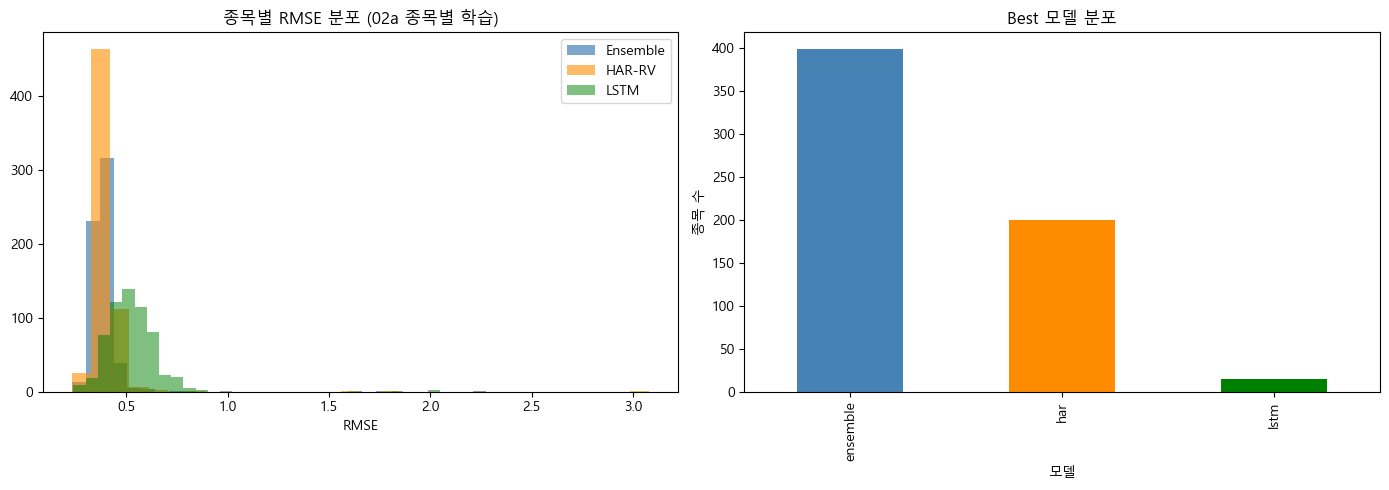

In [16]:
# 4-3. Best 모델 분포
best_model = rmse_by_ticker.apply(
    lambda row: 'lstm' if row['rmse_lstm'] == min(row['rmse_lstm'], row['rmse_har'], row['rmse_ensemble'])
               else ('har' if row['rmse_har'] == min(row['rmse_lstm'], row['rmse_har'], row['rmse_ensemble'])
                    else 'ensemble'),
    axis=1
)
print('=== Best 모델 분포 ===')
print(best_model.value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE 분포
axes[0].hist(rmse_by_ticker['rmse_ensemble'], bins=30, alpha=0.7, label='Ensemble', color='steelblue')
axes[0].hist(rmse_by_ticker['rmse_har'], bins=30, alpha=0.6, label='HAR-RV', color='darkorange')
axes[0].hist(rmse_by_ticker['rmse_lstm'], bins=30, alpha=0.5, label='LSTM', color='green')
axes[0].set_title('종목별 RMSE 분포 (02a 종목별 학습)', fontsize=12)
axes[0].set_xlabel('RMSE')
axes[0].legend()

# Best 모델 분포
best_model.value_counts().plot(kind='bar', ax=axes[1], color=['steelblue', 'darkorange', 'green'])
axes[1].set_title('Best 모델 분포', fontsize=12)
axes[1].set_xlabel('모델')
axes[1].set_ylabel('종목 수')

plt.tight_layout()
plt.savefig(OUT_DIR / 'rmse_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## §5. Phase 1.5 v8 결과 비교

Phase 1.5 v8 (74 종목, 6 년 2020~2025) vs Phase 3 (확장 universe, 17 년 2009~2025).


In [17]:
from scripts.setup import PHASE2_DIR

phase2_ens_path = PHASE2_DIR / 'data' / 'ensemble_predictions_top50.csv'
if phase2_ens_path.exists():
    phase2_ens = pd.read_csv(phase2_ens_path, parse_dates=['date'])

    # Phase 2 와 공통 종목
    common_tickers = set(ensemble_sw['ticker'].unique()) & set(phase2_ens['ticker'].unique())
    print(f'공통 종목 수: {len(common_tickers)}')

    # Phase 2 vs Phase 3 RMSE 비교 (공통 종목 + 2021 이후 공통 기간)
    sw_sub = ensemble_sw[
        (ensemble_sw['ticker'].isin(common_tickers)) &
        (ensemble_sw['date'] >= '2021-01-01')
    ]
    p2_sub = phase2_ens[
        (phase2_ens['ticker'].isin(common_tickers)) &
        (phase2_ens['date'] >= '2021-01-01')
    ]

    sw_rmse = sw_sub.groupby('ticker').apply(
        lambda df: rmse(df['y_true'].values, df['y_pred_ensemble'].values)
    ).mean()
    p2_rmse = p2_sub.groupby('ticker').apply(
        lambda df: rmse(df['y_true'].values, df['y_pred_ensemble'].values)
    ).mean()

    print(f'Phase 2 Ensemble RMSE (2021+): {p2_rmse:.4f}')
    print(f'Phase 3 Stockwise RMSE (2021+): {sw_rmse:.4f}')
    print(f'차이 (Phase 3 - Phase 2): {sw_rmse - p2_rmse:+.4f}')
else:
    print(f'Phase 2 ensemble 파일 없음: {phase2_ens_path}')

공통 종목 수: 74
Phase 2 Ensemble RMSE (2021+): 0.3294
Phase 3 Stockwise RMSE (2021+): 0.3301
차이 (Phase 3 - Phase 2): +0.0007


C:\Users\gorhk\AppData\Local\Temp\ipykernel_24564\1003798313.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sw_rmse = sw_sub.groupby('ticker').apply(
C:\Users\gorhk\AppData\Local\Temp\ipykernel_24564\1003798313.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  p2_rmse = p2_sub.groupby('ticker').apply(


In [18]:
# 최종 요약
print('=== Phase 3 Step 2a 완료 ===')
print(f'산출물: {DATA_DIR / "ensemble_predictions_stockwise.csv"}')
print(f'종목 수: {ensemble_sw["ticker"].nunique()}')
print(f'기간: {ensemble_sw["date"].min().date()} ~ {ensemble_sw["date"].max().date()}')
print()
print('다음 단계:')
print('  02b_phase15_cross_sectional.ipynb   (Cross-Sectional 학습)')
print('  03_BL_backtest_extended.ipynb        (BL 백테스트 — 02a + 02b 완료 후)')

=== Phase 3 Step 2a 완료 ===
산출물: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\data\ensemble_predictions_stockwise.csv
종목 수: 613
기간: 2007-04-23 ~ 2025-12-01

다음 단계:
  02b_phase15_cross_sectional.ipynb   (Cross-Sectional 학습)
  03_BL_backtest_extended.ipynb        (BL 백테스트 — 02a + 02b 완료 후)


## §6. 빠른 BL 백테스트 sanity check (02a 단독, 02b 학습 전)

> 02b cross-sectional 학습 완료 전에 **02a stockwise ensemble 만으로** BL 적용 가능성을 빠르게 검증.

**3 시나리오 비교**:
| 시나리오 | P 행렬 입력 |
|---|---|
| **BL_ml_sw** | 02a stockwise ensemble 예측 변동성 |
| **BL_trailing** | trailing vol_21d (서윤범 99 baseline 재현) |
| **SPY** | 시장 벤치마크 |

**모듈 활용** (`scripts.black_litterman`, `scripts.covariance`):
- `compute_pi(... lam_fixed=2.5)` — 서윤범 99 일관 LAM
- `build_P(... pct=0.30)` — 양극단 30% long/short
- `compute_omega`, `black_litterman(... tau=0.1)`, `optimize_portfolio`
- `estimate_covariance(daily_ret) → Σ_monthly` (LedoitWolf + ×21)

> 본 섹션은 **빠른 검증용 (BL_ml_sw 동작 여부 + 대략적 Sharpe)**. 정식 6 시나리오 백테스트는 03 노트북 참조.

In [ ]:
# §6-1. 데이터 로드 + 사전 준비
from scripts.black_litterman import (
    compute_pi, build_P, compute_omega, black_litterman, optimize_portfolio,
    Q_FIXED, PCT_GROUP, DEFAULT_TAU, LAM_FIXED,
)
from scripts.covariance import estimate_covariance, DAYS_PER_MONTH

# panel + market
panel = pd.read_csv(
    DATA_DIR / 'daily_panel.csv', parse_dates=['date'],
    usecols=['date', 'ticker', 'log_ret', 'vol_21d', 'mcap_value', 'rf_daily'],
)
market = pd.read_csv(DATA_DIR / 'market_data.csv', index_col='date', parse_dates=True)
spy_daily = market['SPY'].pct_change().dropna()
spy_lr = np.log(1 + spy_daily)

# rf 일별
rf_daily = panel.groupby('date')['rf_daily'].mean()
rf_lr = rf_daily.reindex(spy_lr.index, method='ffill').fillna(0)

# 시장 risk premium (월별 환산)
spy_excess_monthly = float((spy_lr - rf_lr).mean() * DAYS_PER_MONTH)
spy_sigma2_monthly = float(spy_lr.var() * DAYS_PER_MONTH)
print(f'spy_excess_monthly: {spy_excess_monthly:.6f} (월 {spy_excess_monthly*100:.2f}%)')
print(f'spy_sigma2_monthly: {spy_sigma2_monthly:.6f}')

# 일별 ret pivot (Σ 추정용)
daily_lr = panel.pivot_table(index='date', columns='ticker', values='log_ret')
print(f'daily_lr: {daily_lr.shape}')

# 학습 종목 (02a)
trained_tickers = set(ensemble_sw['ticker'].unique())
print(f'학습 종목: {len(trained_tickers)}')

# 매월 리밸런싱 시점 (market 거래일 월말)
reb_dates = market.groupby(market.index.to_period('M')).tail(1).index
reb_dates = reb_dates[(reb_dates >= '2009-01-01') & (reb_dates <= '2025-12-31')]
month_to_eom = {pd.Timestamp(d).to_period('M'): pd.Timestamp(d) for d in reb_dates}
print(f'리밸런싱 시점: {len(reb_dates)} 개월')

# ML 예측 월별 피벗 (rebalance date 기준)
ens_copy = ensemble_sw.copy()
ens_copy['month'] = ens_copy['date'].dt.to_period('M')
ml_monthly = ens_copy.groupby(['ticker', 'month'])['y_pred_ensemble'].last().reset_index()
ml_monthly['rebalance_date'] = ml_monthly['month'].map(month_to_eom)
ml_monthly = ml_monthly.dropna(subset=['rebalance_date'])
ml_pred_pivot = ml_monthly.pivot_table(
    index='rebalance_date', columns='ticker', values='y_pred_ensemble'
)
print(f'ml_pred_pivot: {ml_pred_pivot.shape}')

In [ ]:
# §6-2. BL 백테스트 walk-forward 루프 (2 시나리오: BL_ml_sw, BL_trailing)
import warnings
warnings.filterwarnings('ignore')

DAYS_IS = 1260            # IS 5년 (서윤범 일관)
MIN_UNIVERSE = 30          # 매월 최소 종목 (서윤범 일관)
MIN_VALID_TIX = 20         # 60% threshold 후 최소 종목

weights_ml = {}
weights_trailing = {}
n_skip = 0
n_sigma_fail = 0

try:
    from tqdm.auto import tqdm
    iterator = tqdm(reb_dates, desc='BL backtest', ncols=100)
except ImportError:
    iterator = reb_dates

for reb_date in iterator:
    # universe = panel 가용 ∩ 학습 615
    panel_at = panel[panel['date'] == reb_date].dropna(
        subset=['vol_21d', 'mcap_value', 'log_ret']
    )
    avail = set(panel_at['ticker']) & trained_tickers
    if len(avail) < MIN_UNIVERSE:
        n_skip += 1
        continue

    # IS 데이터
    is_end = reb_date
    is_start = is_end - pd.offsets.BDay(DAYS_IS)
    is_data = daily_lr.loc[is_start:is_end, :]
    cols_in_data = [t for t in avail if t in is_data.columns]
    valid_tix = [t for t in cols_in_data
                  if is_data[t].notna().sum() >= int(DAYS_IS * 0.7)]
    if len(valid_tix) < MIN_VALID_TIX:
        n_skip += 1
        continue

    # Σ 추정 (LedoitWolf + ×21)
    try:
        Sigma = estimate_covariance(is_data[valid_tix].dropna())
    except Exception:
        n_sigma_fail += 1
        continue

    # 공통 종목 (Σ ∩ panel mcap)
    panel_idx = panel_at.set_index('ticker')
    mcap = panel_idx['mcap_value'].reindex(Sigma.index).dropna()
    common = list(mcap.index)
    if len(common) < MIN_VALID_TIX:
        n_skip += 1
        continue

    Sigma_c = Sigma.loc[common, common]
    mcap_c = mcap[common]
    w_mkt = mcap_c / mcap_c.sum()

    # CAPM 역산 (서윤범 99: lam_fixed=2.5)
    pi, lam = compute_pi(Sigma_c, w_mkt, spy_excess_monthly, spy_sigma2_monthly,
                          lam_fixed=LAM_FIXED)

    # 시나리오 1: BL_ml_sw (ML 예측)
    if reb_date in ml_pred_pivot.index:
        vol_ml = ml_pred_pivot.loc[reb_date].reindex(common).dropna()
        # log-RV → 실제 vol 환산 (rank only, 단위 무관하지만 양수 보장)
        vol_ml_actual = np.exp(vol_ml)
        if len(vol_ml_actual) >= 5:
            P_ml = build_P(vol_ml_actual, mcap_c[vol_ml_actual.index], pct=PCT_GROUP)
            P_ml = P_ml.reindex(common).fillna(0)
            omega_ml = compute_omega(P_ml, Sigma_c, DEFAULT_TAU)
            mu_ml = black_litterman(pi, Sigma_c, P_ml, q=Q_FIXED,
                                     omega=omega_ml, tau=DEFAULT_TAU)
            w_ml = optimize_portfolio(mu_ml, Sigma_c, lam)
            weights_ml[reb_date] = w_ml

    # 시나리오 2: BL_trailing (vol_21d trailing)
    vol_t = panel_idx['vol_21d'].reindex(common).dropna()
    if len(vol_t) >= 5:
        P_t = build_P(vol_t, mcap_c[vol_t.index], pct=PCT_GROUP)
        P_t = P_t.reindex(common).fillna(0)
        omega_t = compute_omega(P_t, Sigma_c, DEFAULT_TAU)
        mu_t = black_litterman(pi, Sigma_c, P_t, q=Q_FIXED,
                                omega=omega_t, tau=DEFAULT_TAU)
        w_t = optimize_portfolio(mu_t, Sigma_c, lam)
        weights_trailing[reb_date] = w_t

print(f'\n결과:')
print(f'  BL_ml_sw 가중치: {len(weights_ml)} 시점')
print(f'  BL_trailing 가중치: {len(weights_trailing)} 시점')
print(f'  Skip (universe 부족): {n_skip}')
print(f'  Σ 추정 실패: {n_sigma_fail}')

In [ ]:
# §6-3. 월별 returns 계산 + 포트폴리오 returns
from scripts.backtest import backtest_strategy

# 종목별 월별 수익률 (market eom 기준)
def compute_monthly_returns_sw(panel_df, tickers, month_to_eom):
    """일별 log_ret 합 → 월별 단순 수익률, market eom 인덱스."""
    sub = panel_df[panel_df['ticker'].isin(tickers)].set_index('date')
    sub['month'] = sub.index.to_period('M')
    monthly_lr = sub.groupby(['ticker', 'month'])['log_ret'].sum().reset_index()
    monthly_lr['date'] = monthly_lr['month'].map(month_to_eom)
    monthly_lr = monthly_lr.dropna(subset=['date'])
    monthly_lr['ret'] = np.exp(monthly_lr['log_ret']) - 1
    return monthly_lr.pivot_table(index='date', columns='ticker', values='ret')

all_tickers = sorted(trained_tickers)
monthly_rets = compute_monthly_returns_sw(panel, all_tickers, month_to_eom)
print(f'monthly_rets: {monthly_rets.shape}')

# forward (현재 가중치 → 다음 달 수익률)
forward_rets = monthly_rets.shift(-1)

# 포트폴리오 수익률 계산
def make_returns(weights_dict, name):
    if not weights_dict:
        return pd.Series(dtype=float, name=name)
    weights_df = pd.DataFrame(weights_dict).T.fillna(0)
    return backtest_strategy(
        weights_history=weights_df,
        returns=forward_rets,
        transaction_cost=0.0,
    ).dropna().rename(name)

ret_ml = make_returns(weights_ml, 'BL_ml_sw')
ret_tr = make_returns(weights_trailing, 'BL_trailing')

# SPY 월별 수익률 (rebalance date 기준)
spy_monthly = (1 + spy_daily).resample('ME').prod() - 1
spy_monthly_at_eom = spy_monthly.reindex(reb_dates, method='nearest')
ret_spy = spy_monthly_at_eom.shift(-1).dropna().rename('SPY')

print(f'\nBL_ml_sw   : {len(ret_ml)} 개월')
print(f'BL_trailing: {len(ret_tr)} 개월')
print(f'SPY        : {len(ret_spy)} 개월')

In [ ]:
# §6-4. 메트릭 계산 (Sharpe / CAGR / MDD) + Fair 비교
def compute_metrics(rets, annual_factor=12):
    if len(rets) == 0:
        return {k: np.nan for k in ['sharpe', 'cagr', 'ann_vol', 'mdd', 'n']}
    ann_ret = rets.mean() * annual_factor
    ann_vol = rets.std() * np.sqrt(annual_factor)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum = (1 + rets).cumprod()
    mdd = (cum / cum.cummax() - 1).min()
    n = len(rets)
    cagr = cum.iloc[-1] ** (annual_factor / n) - 1 if n > 0 else np.nan
    return {
        'sharpe': sharpe,
        'cagr_%': cagr * 100,
        'ann_vol_%': ann_vol * 100,
        'mdd_%': mdd * 100,
        'n_months': n,
    }

# Fair 비교: 공통 기간 (3 시나리오 교집합)
common_idx = ret_ml.index.intersection(ret_tr.index).intersection(ret_spy.index)
ret_ml_fair = ret_ml.reindex(common_idx).dropna()
ret_tr_fair = ret_tr.reindex(common_idx).dropna()
ret_spy_fair = ret_spy.reindex(common_idx).dropna()

print(f'공통 기간: {common_idx[0].date()} ~ {common_idx[-1].date()} ({len(common_idx)} 개월)')
print()

metrics_table = pd.DataFrame({
    'BL_ml_sw': compute_metrics(ret_ml_fair),
    'BL_trailing': compute_metrics(ret_tr_fair),
    'SPY': compute_metrics(ret_spy_fair),
}).T.round(3)

print('=== 3 시나리오 Fair 비교 ===')
print(metrics_table.to_string())

# ML vs Trailing 차이
delta_sharpe = metrics_table.loc['BL_ml_sw', 'sharpe'] - metrics_table.loc['BL_trailing', 'sharpe']
delta_cagr = metrics_table.loc['BL_ml_sw', 'cagr_%'] - metrics_table.loc['BL_trailing', 'cagr_%']
delta_mdd = metrics_table.loc['BL_ml_sw', 'mdd_%'] - metrics_table.loc['BL_trailing', 'mdd_%']

print()
print('=== ML 통합 효과 (BL_ml_sw - BL_trailing) ===')
print(f'  Sharpe 차이: {delta_sharpe:+.3f}')
print(f'  CAGR 차이:   {delta_cagr:+.2f}%')
print(f'  MDD 차이:    {delta_mdd:+.2f}%  (음수 = ML 이 손실 더 큼)')

# 서윤범 99 비교 (참고)
print()
print('=== 서윤범 99 baseline 참고 ===')
print('  보고 Sharpe: 1.065 (재계산 1.157)')
print(f'  Phase 3 BL_trailing Sharpe (현재): {metrics_table.loc["BL_trailing", "sharpe"]:.3f}')
print(f'  차이: {(metrics_table.loc["BL_trailing", "sharpe"] - 1.157) / 1.157 * 100:+.2f}% from 서윤범 (재계산)')

In [ ]:
# §6-5. 시각화 (누적 수익률 + Drawdown + Rolling Sharpe)
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

COLORS = {
    'BL_ml_sw': '#1f77b4',
    'BL_trailing': '#d62728',
    'SPY': '#8c564b',
}

returns_dict = {
    'BL_ml_sw': ret_ml_fair,
    'BL_trailing': ret_tr_fair,
    'SPY': ret_spy_fair,
}

# 1. 누적 수익률
ax = axes[0]
for s, r in returns_dict.items():
    if len(r) > 0:
        cum = (1 + r).cumprod()
        ax.plot(cum.index, cum.values, label=s, color=COLORS[s], linewidth=1.8)
ax.set_title('누적 수익률 (Fair 비교)', fontsize=12)
ax.set_ylabel('누적 수익 (1=기준)')
ax.legend(loc='upper left'); ax.grid(alpha=0.3)

# 2. Drawdown
ax = axes[1]
for s, r in returns_dict.items():
    if len(r) > 0:
        cum = (1 + r).cumprod()
        dd = (cum / cum.cummax() - 1) * 100
        ax.plot(dd.index, dd.values, label=s, color=COLORS[s], linewidth=1.5)
ax.set_title('Drawdown (%)', fontsize=12)
ax.set_ylabel('Drawdown (%)')
ax.legend(loc='lower left'); ax.grid(alpha=0.3)

# 3. Rolling Sharpe (12 개월)
ax = axes[2]
for s, r in returns_dict.items():
    if len(r) >= 12:
        roll_sharpe = r.rolling(12).apply(
            lambda x: x.mean() / x.std() * np.sqrt(12) if x.std() > 0 else np.nan
        )
        ax.plot(roll_sharpe.index, roll_sharpe.values, label=s, color=COLORS[s], linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Rolling Sharpe (12개월)', fontsize=12)
ax.set_ylabel('Rolling Sharpe')
ax.legend(loc='upper left'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'bl_sanity_check.png', dpi=100, bbox_inches='tight')
plt.show()

print('\n✅ 02a Stockwise BL 백테스트 sanity check 완료')
print(f'  시각화 저장: {OUT_DIR / "bl_sanity_check.png"}')
print()
print('판정 기준:')
print(f'  - BL_trailing Sharpe ≈ 1.0~1.2 → 서윤범 99 재현 OK')
print(f'  - BL_ml_sw Sharpe > BL_trailing → ML 통합 효과 양성')
print(f'  - BL_ml_sw Sharpe < BL_trailing → ML 통합 효과 미미 또는 역효과')
print()
print('💡 정식 6 시나리오 (+EW, +Mcap, +BL_ml_cs) 평가는 02b 완료 후 03 노트북.')